# Testing
bfs_hotelgaeste_flughafenregion_od1105

## Hotelgäste in der Flughafenregion
Datum: 27.01.2025

### Kurzbeschreibung
Diese Daten beinhalten Zahlen zu den Hotelgästen in der Flughafenregion.

Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bfs_hotelgaeste_flughafenregion_od1105

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_hotelgaeste_flughafenregion_od1105

### Importiere die notwendigen Packages

In [44]:
#%pip install altair folium geopandas matplotlib numpy pandas plotly requests seaborn

In [45]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [46]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [47]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [48]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [49]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [50]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [51]:
package_name = "bfs_hotelgaeste_flughafenregion_od1105"

In [52]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "WIR110OD1105"    
    , datums_attr = ['StichtagDatMMYY']
    , na_values= ['K']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_hotelgaeste_flughafenregion_od1105/download/WIR110OD1105.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bfs_hotelgaeste_flughafenregion_od1105 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bfs_hotelgaeste_flughafenregion_od1105 

data_source: web


In [53]:
data2betested.tail(2).T

,1574,1575
StichtagDatMMYY,2025-10-01 00:00:00,2025-10-01 00:00:00
Kennzahl,Logiernächte,Logiernächte
Herkunft,Inland,Ausland
Anzahl,79461,82985


Berechne weitere Attribute falls notwendig

In [54]:
data2betested = (
    data2betested
    .copy()
    .assign(
        Jahr_Monat = lambda x: x.StichtagDatMMYY,
        Jahr_nbr = lambda x: x.Jahr_Monat.dt.year,
        Jahr_Monat_end = lambda x: x.StichtagDatMMYY+pd.offsets.MonthEnd(0),
        #Jahr_Monat_str = lambda x: x.StichtagDatMMYY.astype(str).str.zfill(2),
        Jahr_Monat_str = lambda x: x.Jahr_Monat_end.astype(str),
    )
    .sort_values('StichtagDatMMYY', ascending=False)
    )
data2betested.dtypes

StichtagDatMMYY    datetime64[ns]
Kennzahl                   object
Herkunft                   object
Anzahl                      int64
Jahr_Monat         datetime64[ns]
Jahr_nbr                    int32
Jahr_Monat_end     datetime64[ns]
Jahr_Monat_str             object
dtype: object

Minimales und maximales Jahr im Datensatz

In [55]:
data_max_date = max(data2betested.Jahr_Monat_end).strftime('%Y-%m-%d')#.strftime('%Y-%m-%d')
data_min_date = min(data2betested.Jahr_Monat_end).strftime('%Y-%m-%d')

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1992-01-31 und ein Maximumjahr von 2025-10-31


### Einfache Datentests

In [56]:
data2betested.sort_values('Jahr_Monat_str', ascending=False).head(2).T

,1575,786
StichtagDatMMYY,2025-10-01 00:00:00,2025-10-01 00:00:00
Kennzahl,Logiernächte,Ankünfte
Herkunft,Ausland,Inland
Anzahl,82985,55949
Jahr_Monat,2025-10-01 00:00:00,2025-10-01 00:00:00
Jahr_nbr,2025,2025
Jahr_Monat_end,2025-10-31 00:00:00,2025-10-31 00:00:00
Jahr_Monat_str,2025-10-31,2025-10-31


In [57]:
#data2betested.dtypes
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1576 entries, 1575 to 788
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   StichtagDatMMYY  1576 non-null   datetime64[ns]
 1   Kennzahl         1576 non-null   object        
 2   Herkunft         1576 non-null   object        
 3   Anzahl           1576 non-null   int64         
 4   Jahr_Monat       1576 non-null   datetime64[ns]
 5   Jahr_nbr         1576 non-null   int32         
 6   Jahr_Monat_end   1576 non-null   datetime64[ns]
 7   Jahr_Monat_str   1576 non-null   object        
dtypes: datetime64[ns](3), int32(1), int64(1), object(3)
memory usage: 408.6 KB


In [58]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 1,576 rows (observations) and 8 columns (variables).
There seem to be 0 exact duplicates in the data.


In [59]:
data2betested.describe()

,StichtagDatMMYY,Anzahl,Jahr_Monat,Jahr_nbr,Jahr_Monat_end
count,1576,1576,1576,1576,1576
mean,2009-01-03 09:44:46.294416128,32205,2009-01-03 09:44:46.294416128,2009,2009-02-01 20:13:24.060913664
min,1992-01-01 00:00:00,945,1992-01-01 00:00:00,1992,1992-01-31 00:00:00
25%,2000-03-01 00:00:00,17069,2000-03-01 00:00:00,2000,2000-03-31 00:00:00
50%,2009-05-16 12:00:00,26936,2009-05-16 12:00:00,2009,2009-06-15 00:00:00
75%,2017-08-01 00:00:00,42435,2017-08-01 00:00:00,2017,2017-08-31 00:00:00
max,2025-10-01 00:00:00,112431,2025-10-01 00:00:00,2025,2025-10-31 00:00:00
std,NaN,20309,NaN,10,NaN


Welches sind die Quartiere ohne Werte bei BEW?

In [60]:
data2betested[np.isnan(data2betested.Anzahl)]

,StichtagDatMMYY,Kennzahl,Herkunft,Anzahl,Jahr_Monat,Jahr_nbr,Jahr_Monat_end,Jahr_Monat_str


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [61]:
data2betested = data2betested.set_index("Jahr_Monat_end")
data2betested = data2betested.sort_index()

In [62]:
data2betested.index.year.unique()

Index([1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2005, 2006, 2007,
       2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023, 2024, 2025],
      dtype='int32', name='Jahr_Monat_end')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [63]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number',datetime_is_numeric=True))
except:
    print("No categorical data in dataset.")

No categorical data in dataset.


Beschreibe numerische Attribute

In [64]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,Anzahl,Jahr_nbr
count,"1,576","1,576"
mean,"32,205","2,009"
std,"20,309",10
min,945,"1,992"
25%,"17,069","2,000"
50%,"26,936","2,009"
75%,"42,435","2,017"
max,"112,431","2,025"


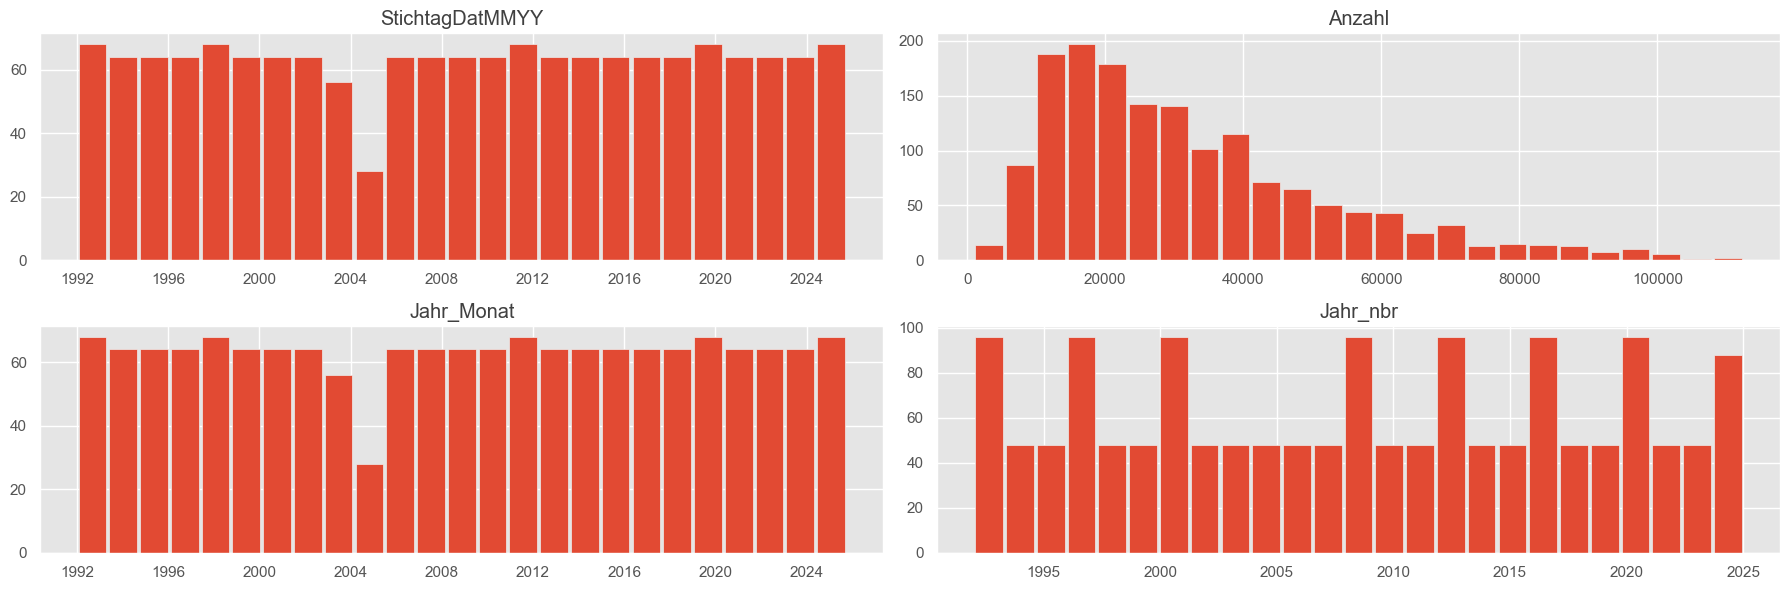

In [65]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [66]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,StichtagDatMMYY,Kennzahl,Herkunft,Anzahl,Jahr_Monat,Jahr_nbr,Jahr_Monat_str
Jahr_Monat_end,,,,,,,


### Nullwerte und Missings?

In [67]:
data2betested.isnull().sum()

StichtagDatMMYY    0
Kennzahl           0
Herkunft           0
Anzahl             0
Jahr_Monat         0
Jahr_nbr           0
Jahr_Monat_str     0
dtype: int64

In [68]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [69]:
agg_jahr = data2betested.loc[data_min_date:data_max_date].reset_index()\
    .groupby(['StichtagDatMMYY', 'Jahr_Monat_end','Jahr_Monat', 'Jahr_nbr','Jahr_Monat_str']) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Jahr_Monat_end', ascending=False) 
agg_jahr.reset_index().head(6)

,StichtagDatMMYY,Jahr_Monat_end,Jahr_Monat,Jahr_nbr,Jahr_Monat_str,sum_Anz
0,2025-10-01,2025-10-31,2025-10-01,2025,2025-10-31,275016
1,2025-09-01,2025-09-30,2025-09-01,2025,2025-09-30,292437
2,2025-08-01,2025-08-31,2025-08-01,2025,2025-08-31,318998
3,2025-07-01,2025-07-31,2025-07-01,2025,2025-07-31,316349
4,2025-06-01,2025-06-30,2025-06-01,2025,2025-06-30,312962
5,2025-05-01,2025-05-31,2025-05-01,2025,2025-05-31,299969


In [70]:
agg_kennzahl = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Kennzahl']) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Kennzahl', ascending=False) 
agg_kennzahl.reset_index().head(6)

,Kennzahl,sum_Anz
0,Logiernächte,30468602
1,Ankünfte,20286515


In [71]:
agg_herk = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Herkunft']) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('sum_Anz', ascending=False) 
agg_herk.reset_index().head(6)

,Herkunft,sum_Anz
0,Ausland,32861245
1,Inland,17893872


In [72]:
data2betested.columns

Index(['StichtagDatMMYY', 'Kennzahl', 'Herkunft', 'Anzahl', 'Jahr_Monat', 'Jahr_nbr',
       'Jahr_Monat_str'],
      dtype='object')

In [73]:
agg_herk_kennz = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Kennzahl','Herkunft']) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Kennzahl', ascending=False) 
agg_herk_kennz.reset_index().head(12)

,Kennzahl,Herkunft,sum_Anz
0,Logiernächte,Ausland,19964869
1,Logiernächte,Inland,10503733
2,Ankünfte,Ausland,12896376
3,Ankünfte,Inland,7390139


### Visualisierungen nach Zeitausschnitten

In [74]:
data2betested.info()
#data2betested

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1576 entries, 1992-01-31 to 2025-10-31
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   StichtagDatMMYY  1576 non-null   datetime64[ns]
 1   Kennzahl         1576 non-null   object        
 2   Herkunft         1576 non-null   object        
 3   Anzahl           1576 non-null   int64         
 4   Jahr_Monat       1576 non-null   datetime64[ns]
 5   Jahr_nbr         1576 non-null   int32         
 6   Jahr_Monat_str   1576 non-null   object        
dtypes: datetime64[ns](2), int32(1), int64(1), object(3)
memory usage: 124.6+ KB


#### Entwicklung der Logiernächte nach Herkunft

In [75]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .query("Kennzahl == 'Logiernächte'") \
    .groupby(['Jahr_Monat_str', 'Jahr_nbr','Kennzahl','Herkunft']) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Kennzahl', ascending=False) 
myAgg1.reset_index().head(2)

,Jahr_Monat_str,Jahr_nbr,Kennzahl,Herkunft,sum_Anz
0,1992-01-31,1992,Logiernächte,Ausland,25548
1,2014-08-31,2014,Logiernächte,Ausland,85979


In [76]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().query('Herkunft !="Ausländeranteil"')
    ,x = 'Jahr_Monat_str:T'
    ,y = 'sum_Anz:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "Herkunft:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Logiernächte nach Herkunft und Monat in der Flughafenregion, seit "+data_min_date
)
grafik1

alt.LayerChart(...)

#### Faced Grids

In [77]:
sns.set_theme(style="whitegrid")

In [78]:
data2betested.columns

Index(['StichtagDatMMYY', 'Kennzahl', 'Herkunft', 'Anzahl', 'Jahr_Monat', 'Jahr_nbr',
       'Jahr_Monat_str'],
      dtype='object')

In [79]:
#.query('HerkunftLang !="Ausland"')
myFG = data2betested\
    .groupby([ 'Jahr_nbr', 'Jahr_Monat_str','Kennzahl', 'Herkunft',]) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Kennzahl', ascending=False) 
myFG.reset_index().head(2)

,Jahr_nbr,Jahr_Monat_str,Kennzahl,Herkunft,sum_Anz
0,2025,2025-10-31,Logiernächte,Inland,79461
1,2019,2019-07-31,Logiernächte,Inland,69908


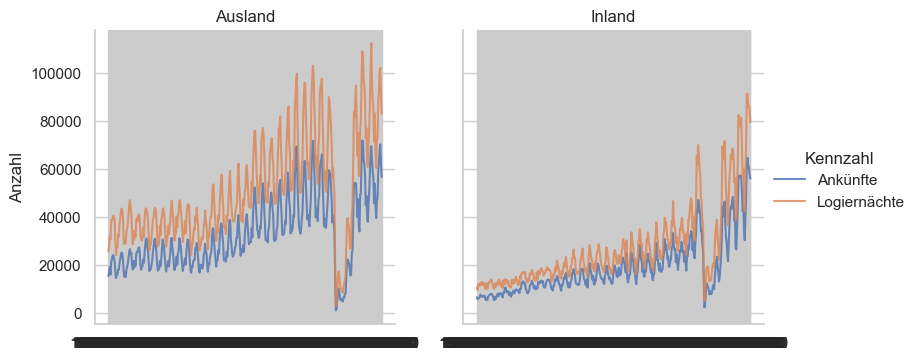

In [80]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('Jahr_Monat_str', ascending=True)
    ,col = "Herkunft"
    ,hue = "Kennzahl"
    ,col_wrap = 2
    ,grafiktyp = sns.lineplot
    ,x = "Jahr_Monat_str"
    ,y = "sum_Anz"
    ,ylabel= "Anzahl"
    ,warning_status ="ignore"
    ,height = 3
    #,myTitle="Wohnbevölkerung nach Altersgruppe und Stadtquartier, seit "+str(int(data2betested.index.year.min()))   
)
faced_grid1

##### Gibt es zeitliche Datenlücken?

In [81]:
#Gibt es eine zeitliche Datenlücke?

timefilter = "2024"
#lücke in der zeitreihe?
ideal_time_range = pd.date_range(start=data2betested.loc[timefilter].index.min(), end=data2betested.loc[timefilter].index.max(), freq='1m') #10h

# Überprüfe, ob es Unterschiede zwischen dem idealen Zeitstempelbereich und dem tatsächlichen Index gibt
missing_timestamps_my = ideal_time_range.difference(data2betested.index)

if missing_timestamps_my.empty:
    print("Keine Lücken in der Zeitreihe gefunden.")
else:
    print("Lücken in der Zeitreihe gefunden:")
    print(missing_timestamps_my)

Keine Lücken in der Zeitreihe gefunden.


### Daten in interaktiver Treemap zeigen
Dazu gibt es eine sehr nützliche Webseite https://plotly.com/python/treemaps/
Zu Farbskalen, siehe: https://plotly.com/python/builtin-colorscales/

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [82]:
  qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
  qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
  qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
  div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
  div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]

In [83]:
data2betested.columns

Index(['StichtagDatMMYY', 'Kennzahl', 'Herkunft', 'Anzahl', 'Jahr_Monat', 'Jahr_nbr',
       'Jahr_Monat_str'],
      dtype='object')

In [84]:
# Extrahiere die Top-Fahrzeugmarken
color_var = data2betested['Herkunft'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(color_var):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Inland': '#0017BF', 'Ausland': '#0072D7'}


#### Hotelgäste betreffend Logiernächten und Ankünften nach Herkunft

In [85]:
myTreemapAgg = data2betested.loc["2020":data_max_date]   \
    .groupby(['StichtagDatMMYY', 'Kennzahl', 'Herkunft', 'Jahr_nbr', 'Jahr_Monat_str' ]) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Jahr_Monat_str', ascending=False) 

myTreemapAgg.reset_index().head(4)

#.query("KreisLang ='Unbekannt'")\


,StichtagDatMMYY,Kennzahl,Herkunft,Jahr_nbr,Jahr_Monat_str,sum_Anz
0,2025-10-01,Logiernächte,Inland,2025,2025-10-31,79461
1,2025-10-01,Logiernächte,Ausland,2025,2025-10-31,82985
2,2025-10-01,Ankünfte,Inland,2025,2025-10-31,55949
3,2025-10-01,Ankünfte,Ausland,2025,2025-10-31,56621


In [86]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTreemapAgg.reset_index()
    ,levels=['Jahr_nbr','Kennzahl', 'Herkunft',]
    ,values="sum_Anz"
    ,color="Herkunft"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    #,color_discrete_map={'(?)':'lightgrey', 'Erwerbstätige':'#99C32E', 'Nichterwerbspersonen':'#7B4100', 'Erwerbslose':'#DB247D'}  
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Hotelgäste in der Flughafenregion, 2020-"+data_max_date

)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x00000202418E7CD0>, 'Jahr_nbr', 'Kennzahl', 'Herkunft']
Typ von path: <class 'list'>


**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://szhglobal.sharepoint.com/sites/ssz-spo-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=462&e=bM5fos)**